The P6 runs converge because agents flip toward the room, not toward an argument: the
flip diagnostic (`polis.responses.flip_report`) showed 100% of flips happened with peer
opinions in context and the utterances are dominated by social-proof language ("I'm with
the ladies", "the consensus here"). This notebook tests two library levers against that,
holding corpus / topology / seed fixed and changing only the levers:

- **heard down-weight** — `RetrievalConfig.kind_weights` makes `heard` memories rank below
  the agent's own seeds/convictions, so fewer peer opinions reach the injected top-N.
- **prompt persistence** — `DynamicsConfig.persistence` adds an anti-sycophancy clause
  ("hold your view unless you hear a genuinely new argument").

The **conviction** arm turns both on; the **baseline** arm is the current engine. The
verdict is read straight from the run logs — flip count, how many flips use social-proof
language, and the dominant-share trajectory — no separate survey needed.

In [1]:
import pandas as pd
from plotnine import ggplot, aes, geom_line, geom_point, labs, scale_x_continuous

from polis import metrics
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient, LLMConfig
from polis.memory import KIND_HEARD, RetrievalConfig
from polis.persona_pipeline import load_corpus
from polis.questions import DST_OPTIONS
from polis.responses import flip_report
from polis.runlog import RunLog
from polis.scheduler import Scheduler, SchedulerConfig
from polis.simulation import DynamicsConfig, Population, Simulation
from polis.topology import SmallWorld
from polis.viz_theme import theme_polis

In [2]:
# --- CONFIG (edit and re-run downward) ----------------------------------------
MODEL     = "anthropic/claude-sonnet-5"
CORPUS    = "data/personas_corpus_n100.json"
N_AGENTS  = 40          # subset for cost; raise to 100 for the full run
TICKS     = 5
SEED      = 42
HEARD_W   = 0.3         # weight on `heard` memories in the conviction arm (1.0 = no change)
SUPPORT   = len(DST_OPTIONS)

# Two arms over identical draws: only the levers differ.
ARMS = {
    "baseline":   dict(retrieval=None,
                       persistence=False),
    "conviction": dict(retrieval=RetrievalConfig(kind_weights=((KIND_HEARD, HEARD_W),)),
                       persistence=True),
}

ABBR = {
    "Adopt permanent standard time (clocks stay on winter time all year: earlier sunrises, earlier sunsets)": "STD",
    "Adopt permanent daylight saving time (clocks stay on summer time all year: later sunrises, later sunsets)": "DST",
    "Keep switching the clocks twice a year": "SWITCH",
    "No preference": "NOPREF",
}

In [3]:
embedder = EmbeddingModel()

def load_subset():
    """Fresh corpus dict truncated to N_AGENTS — each arm gets its own population so
    memory state never leaks between arms."""
    corpus = load_corpus(CORPUS)
    corpus["personas"] = corpus["personas"][:N_AGENTS]
    return corpus

print(f"corpus has {len(load_subset()['personas'])} personas for this run")

corpus has 40 personas for this run


## Run both arms

Each arm: a fresh `Population.from_corpus` (with the arm's retrieval config), a `SmallWorld`
topology, and a `DynamicsConfig` carrying the arm's `persistence` flag. Same seed, same
topology, same corpus subset — so any difference is the levers. Both configs are versioned
into the run log (R17); the `persistence` flag and `kind_weights` are in `_build_config`.

In [4]:
runs = {}
for name, arm in ARMS.items():
    client = LLMClient(LLMConfig(model=MODEL, reasoning=None))
    pop = Population.from_corpus(load_subset(), client=client, embedder=embedder,
                                 retrieval=arm["retrieval"])
    sim = Simulation(
        pop,
        topology=SmallWorld(k=4, p=0.3, seed=SEED),
        dynamics=DynamicsConfig(seed=SEED, persistence=arm["persistence"]),
        logger=RunLog.open(f"data/phase6_conviction_{name}.sqlite"),
        scheduler=Scheduler(SchedulerConfig(max_concurrency=16, max_retries=4)),
    )
    print(f"[{name}] running {N_AGENTS} agents × {TICKS} ticks "
          f"(persistence={arm['persistence']}, heard_w={arm['retrieval'] and HEARD_W})…")
    runs[name] = sim.run(TICKS)
    print(f"[{name}] done: {runs[name].throughput['n_calls']} decides")

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7369.34it/s]

[baseline] running 40 agents × 5 ticks (persistence=False, heard_w=None)…


[baseline] done: 200 decides


[conviction] running 40 agents × 5 ticks (persistence=True, heard_w=0.3)…


[conviction] done: 200 decides


## Verdict 1 — flip volume and how many are social-proof

`flip_report` returns every stance change joined to the utterance and the peer-opinion
count at that tick. The lever works if the **conviction** arm has fewer flips and a lower
share of `references_others` (agreement/consensus language) flips.

In [5]:
rows = []
flip_frames = {}
for name in ARMS:
    rep = flip_report(runs[name])
    flip_frames[name] = rep
    rows.append({
        "arm": name,
        "flips": len(rep),
        "flips_per_agent": round(len(rep) / N_AGENTS, 2),
        "pct_references_others": round(100 * rep["references_others"].mean(), 0) if len(rep) else 0,
        "mean_heard_at_flip": round(rep["n_heard"].mean(), 2) if len(rep) else 0,
    })
pd.DataFrame(rows).set_index("arm")

,flips,flips_per_agent,pct_references_others,mean_heard_at_flip
arm,,,,
baseline,19,0.47,53.0,3.05
conviction,26,0.65,38.0,3.00


The net stance flow per arm — the baseline should show the heavy `SWITCH→STD` / `DST→STD`
collapse toward the prior; the conviction arm should show fewer moves overall.

In [6]:
for name in ARMS:
    rep = flip_frames[name]
    if len(rep):
        flow = (rep.assign(f=rep["from_stance"].map(ABBR), t=rep["to_stance"].map(ABBR))
                   .groupby(["f", "t"]).size().sort_values(ascending=False))
        print(f"\n[{name}] net flow:")
        print(flow.to_string())


[baseline] net flow:
f       t     
SWITCH  STD       16
STD     SWITCH     3

[conviction] net flow:
f       t     
SWITCH  STD       18
STD     SWITCH     7
SWITCH  DST        1


## Verdict 2 — dominant-share trajectory

Convergence over ticks, computed offline from each run log. The lever works if the
conviction arm's dominant share rises more slowly / plateaus lower.

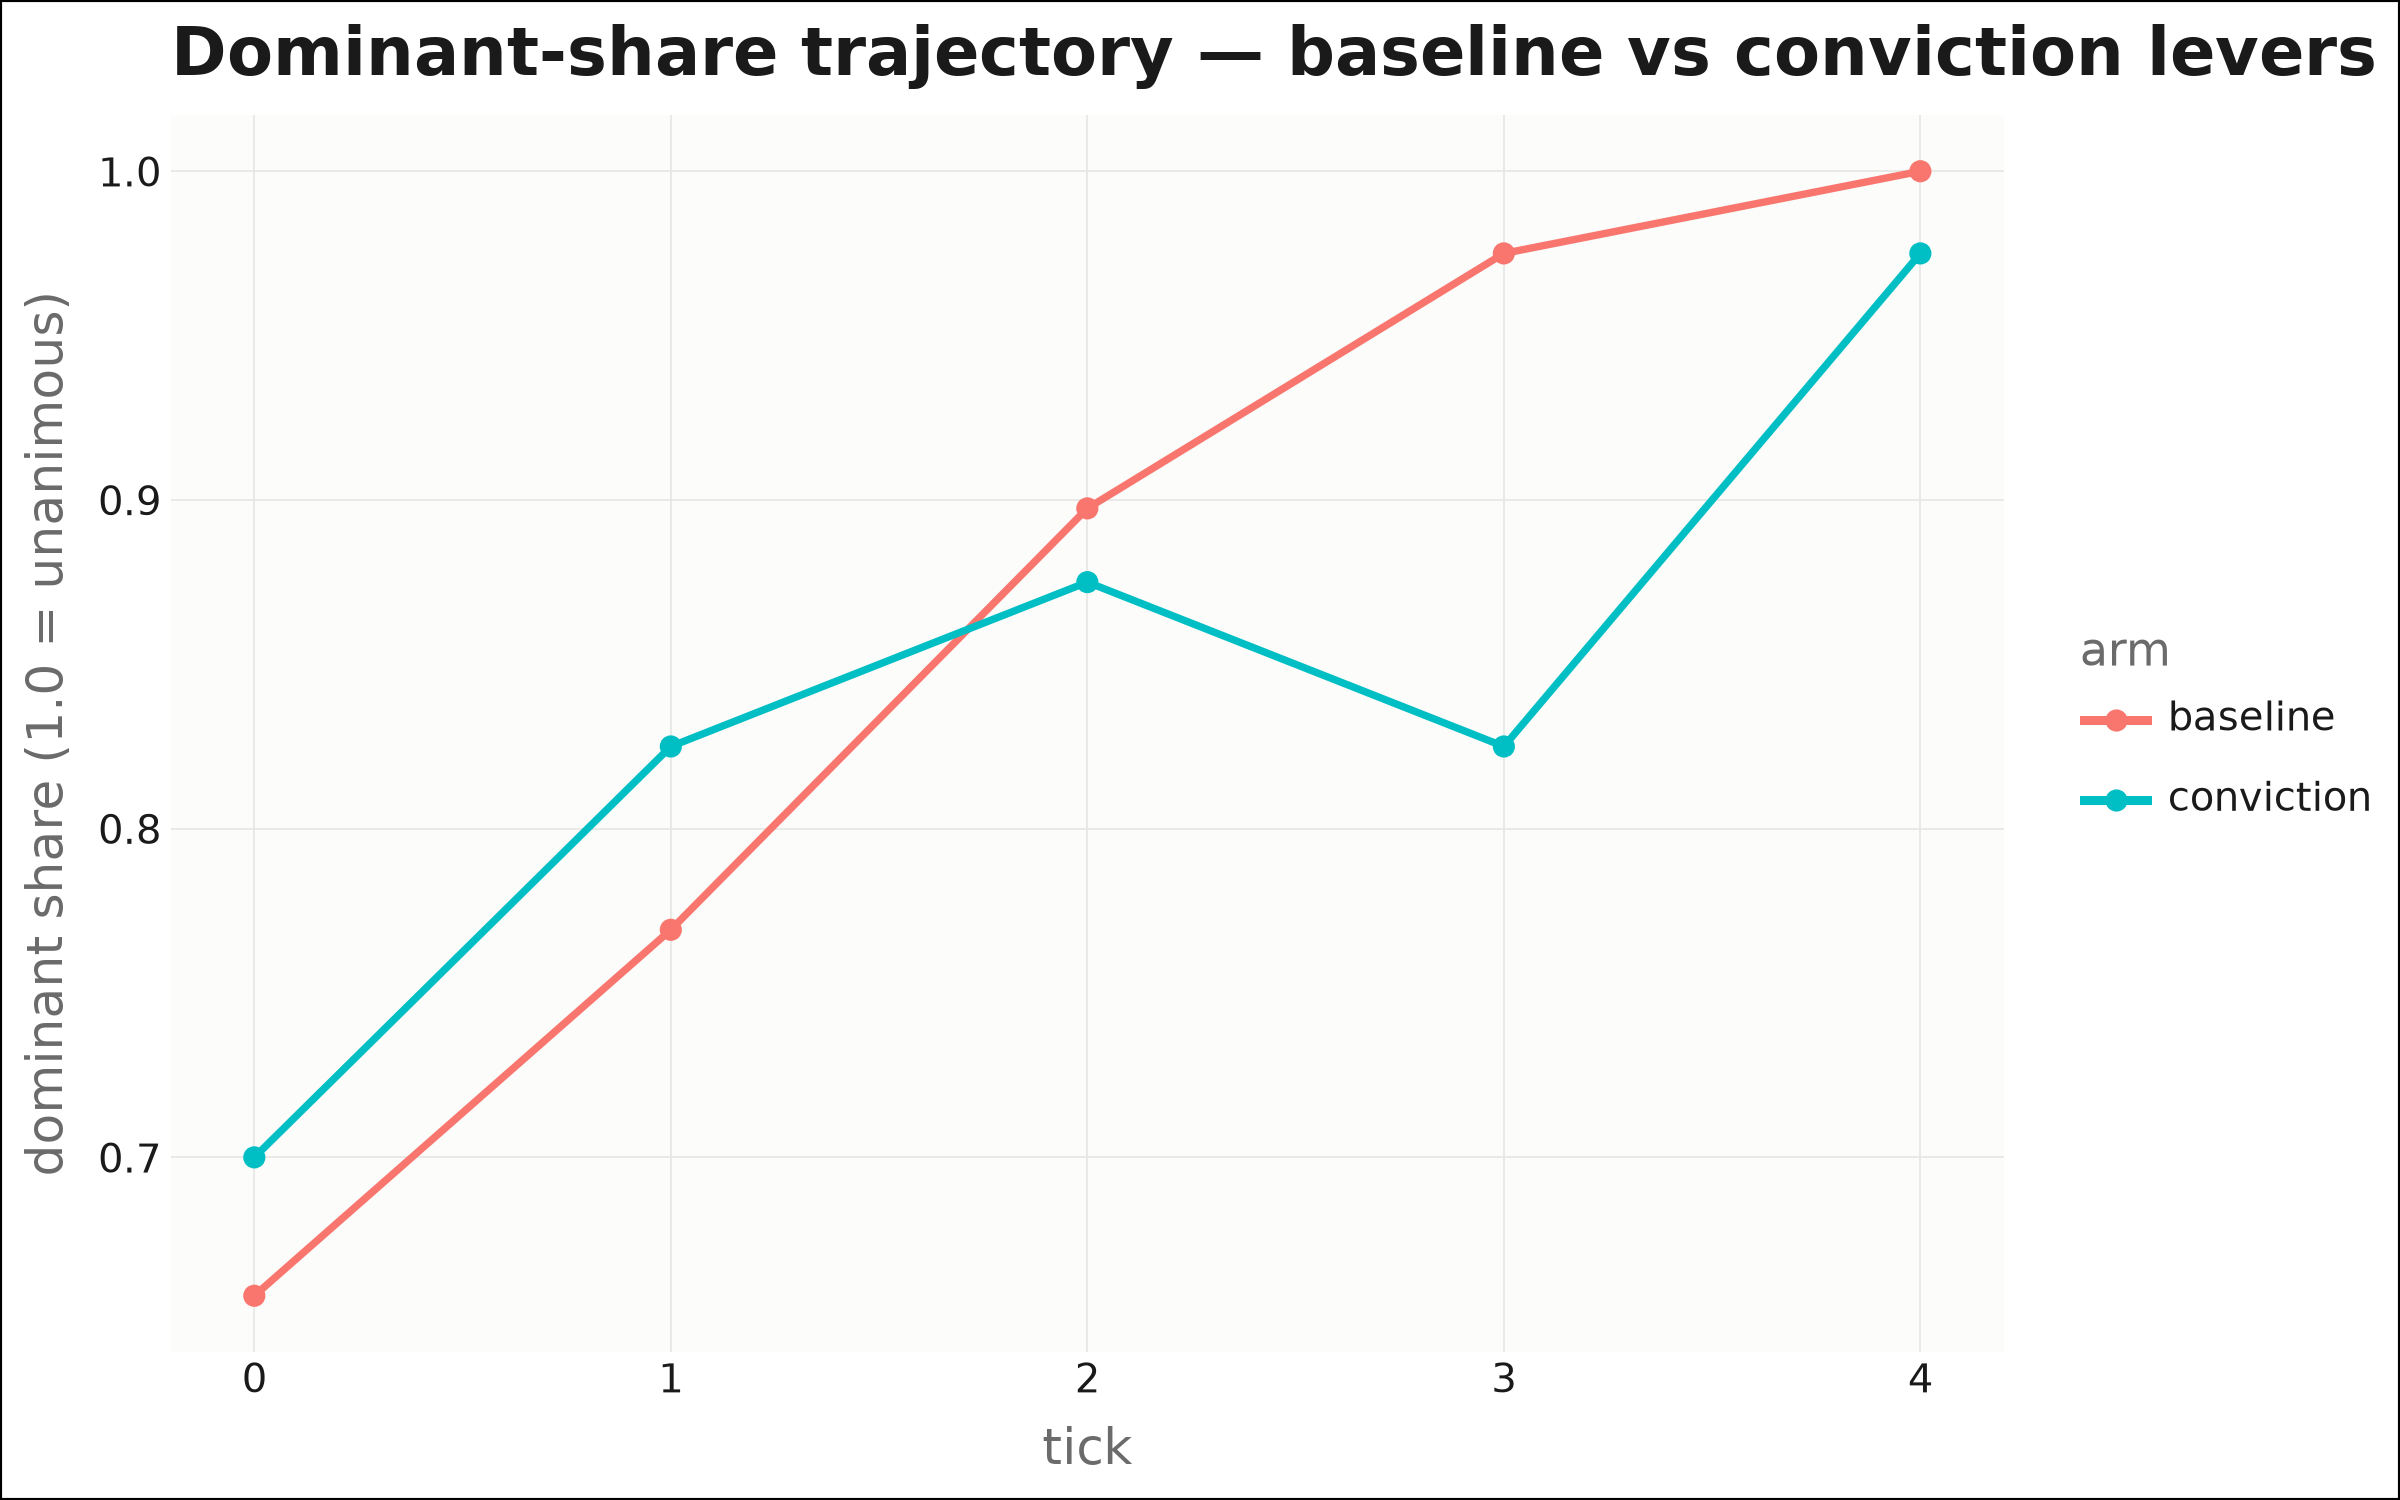

In [7]:
traj = []
for name in ARMS:
    for r in metrics.divergence_trajectory(runs[name], embedder, support=SUPPORT):
        traj.append({"arm": name, "tick": r["tick"], "dominant_share": r["dominant_share"],
                     "entropy": r["entropy"]})
traj = pd.DataFrame(traj)
(
    ggplot(traj, aes("tick", "dominant_share", color="arm"))
    + geom_line(size=1) + geom_point(size=2)
    + labs(title="Dominant-share trajectory — baseline vs conviction levers",
           x="tick", y="dominant share (1.0 = unanimous)", color="arm")
    + scale_x_continuous(breaks=sorted(traj["tick"].unique()))
    + theme_polis()
)

In [8]:
# persist for later inspection
traj.to_csv("data/phase6_conviction_trajectory.csv", index=False)
pd.DataFrame(rows).to_csv("data/phase6_conviction_flips.csv", index=False)
print("wrote data/phase6_conviction_trajectory.csv and _flips.csv")

wrote data/phase6_conviction_trajectory.csv and _flips.csv


## Read

If the conviction arm moves the flip share and the trajectory, the levers are worth
adopting (and deserve an ADR amending the dynamics defaults). If it barely moves — as
several earlier fixes did — that itself is the finding: the pull is the model's
standard-time prior leaking through *content*, not just the social channel, which points
back to the demographic-gradient / prior work (issue #1–2) rather than more dynamics knobs.
```